In [99]:
## Setup: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from category_encoders import OneHotEncoder



In [100]:
# Define the path to our data file
path_1 = "../data/mexico-city-real-estate-1.csv"
print(f'Load data from: "{path_1}"')
asf1=pd.read_csv(path_1)
asf1.head()

Load data from: "../data/mexico-city-real-estate-1.csv"


,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Miguel Hidalgo|Distrito Federal|México|,"23.634501,-102.552788",5500000.0,MXN,5450245.50,289775.66,NaN,54.0,NaN,101851.851900,NaN,NaN,NaN,http://miguel-hidalgo-df.properati.com.mx/o3zb...
1,sell,house,|Iztapalapa|Distrito Federal|México|,"19.31033,-99.068557",1512000.0,MXN,1498321.97,79661.96,NaN,80.0,NaN,18900.000000,NaN,NaN,NaN,http://iztapalapa.properati.com.mx/q7t0_venta_...
2,sell,apartment,|Tlalpan|Distrito Federal|México|,"19.279771,-99.234597",926667.0,MXN,918284.00,48822.82,NaN,100.0,NaN,9266.670000,NaN,NaN,NaN,http://tlalpan.properati.com.mx/qbi4_venta_dep...
3,sell,apartment,|Miguel Hidalgo|Distrito Federal|México|,"23.634501,-102.552788",6410000.0,MXN,6352013.39,337720.36,NaN,135.0,NaN,47481.481480,NaN,NaN,NaN,http://miguel-hidalgo-df.properati.com.mx/opeq...
4,sell,apartment,|Benito Juárez|Quintana Roo|México|,"21.1902642,-86.8198375",875000.0,USD,16457437.50,875000.00,0.0,263.0,NaN,3326.996198,NaN,NaN,NaN,http://cancun.properati.com.mx/hg4t_venta_depa...


In [101]:
paths = [
    "../data/mexico-city-real-estate-2.csv",
    "../data/mexico-city-real-estate-3.csv",
    "../data/mexico-city-real-estate-4.csv",
    "../data/mexico-city-real-estate-5.csv",
]

extra_dfs = []
for path in paths:
    print(f'Load data from: "{path}"')
    extra_dfs.append(pd.read_csv(path))

extra_dfs[0].head()

Load data from: "../data/mexico-city-real-estate-2.csv"
Load data from: "../data/mexico-city-real-estate-3.csv"
Load data from: "../data/mexico-city-real-estate-4.csv"
Load data from: "../data/mexico-city-real-estate-5.csv"


,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Gustavo A. Madero|Distrito Federal|México|,"19.516777,-99.160149",1200000.0,MXN,1189144.46,63223.78,88.0,88.0,718.452046,13636.36364,NaN,NaN,NaN,http://gustavo-a-madero.properati.com.mx/r644_...
1,sell,apartment,|Gustavo A. Madero|Distrito Federal|México|,"19.466724,-99.131614",480000.0,MXN,475657.74,25289.51,NaN,48.0,NaN,10000.00000,NaN,NaN,NaN,http://vallejo.properati.com.mx/mz4c_venta_dep...
2,sell,apartment,|Álvaro Obregón|Distrito Federal|México|,"19.33228,-99.243934",4559261.0,MXN,4518016.68,240211.43,NaN,126.0,NaN,36184.61111,NaN,NaN,NaN,http://alvaro-obregon.properati.com.mx/jh8j_ve...
3,sell,apartment,|Benito Juárez|Quintana Roo|México|,"21.1105772788,-86.8537859927",3808088.0,MXN,3774533.79,200682.34,0.0,171.0,NaN,22269.52047,NaN,NaN,NaN,http://cancun.properati.com.mx/qus8_venta_depa...
4,sell,apartment,|Benito Juárez|Distrito Federal|México|,"19.39365,-99.14769",1730000.0,MXN,1714349.82,91147.61,NaN,100.0,NaN,17300.00000,NaN,NaN,NaN,http://benito-juarez.properati.com.mx/q5my_ven...


In [102]:
all_dfs = [asf1] + extra_dfs
column_match = all(set(df) == set(asf1) for df in all_dfs) # Column Validation
if column_match:
    print(f'The features of all {len(all_dfs)} datasets match')
    real_estate_df = pd.concat(all_dfs, ignore_index=True) # Conditional Concatenation
    print('Concatenation successful')
else:
    raise Exception('The features of the datasets do not match')

The features of all 5 datasets match
Concatenation successful


# Data Exploration
- Checking the initial shape of dataset alongside it's information, data types and null values

In [103]:
# Checking the shape of dataset i.e. no. of rows and columns: (r,c)
real_estate_df.shape

(23140, 16)

In [104]:
# Checking information regarding the datasets such as class, index range, and different column names as well as their datatypes as well as their non-null count.
real_estate_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23140 entries, 0 to 23139
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   23140 non-null  str    
 1   property_type               23140 non-null  str    
 2   place_with_parent_names     23140 non-null  str    
 3   lat-lon                     20698 non-null  str    
 4   price                       22745 non-null  float64
 5   currency                    22745 non-null  str    
 6   price_aprox_local_currency  22745 non-null  float64
 7   price_aprox_usd             22745 non-null  float64
 8   surface_total_in_m2         8633 non-null   float64
 9   surface_covered_in_m2       22215 non-null  float64
 10  price_usd_per_m2            6012 non-null   float64
 11  price_per_m2                21320 non-null  float64
 12  floor                       1531 non-null   float64
 13  rooms                       621 non-null  

In [105]:
# This feels redundant but I was taught that this is the standard process so we do it anyway. I don't know why we do it but maybe I will understand it in future.
real_estate_df.dtypes

operation                         str
property_type                     str
place_with_parent_names           str
lat-lon                           str
price                         float64
currency                          str
price_aprox_local_currency    float64
price_aprox_usd               float64
surface_total_in_m2           float64
surface_covered_in_m2         float64
price_usd_per_m2              float64
price_per_m2                  float64
floor                         float64
rooms                         float64
expenses                      float64
properati_url                     str
dtype: object

In [106]:
# While we did something similar in the previous cell, I don't feel this is a redundant step, it specifies exactly the total amount of null values in each column and depending on the info , we can decide whether we want to impute, drop or leave the values. To showcase imputation and null, I will do both here on numeric and categorical features respectively.
real_estate_df.isnull().sum()

operation                         0
property_type                     0
place_with_parent_names           0
lat-lon                        2442
price                           395
currency                        395
price_aprox_local_currency      395
price_aprox_usd                 395
surface_total_in_m2           14507
surface_covered_in_m2           925
price_usd_per_m2              17128
price_per_m2                   1820
floor                         21609
rooms                         22519
expenses                      23126
properati_url                     0
dtype: int64

# Data Cleaning
Drop irrelevant columns, convert data types and derive features as per need. To handle missing values, I use linear interpolation for numeric features in this case. For the categorical features, I drop them.

In [107]:
# Dropping irrelevant columns

real_estate_df = real_estate_df.drop(columns=[
    'operation', 'currency', 'price', 'price_aprox_local_currency',
    'price_usd_per_m2', 'floor', 'rooms', 'expenses',
    'properati_url', 'price_per_m2', 'surface_total_in_m2'
])

In [108]:
# Data type conversion.
real_estate_df["place_with_parent_names"] = real_estate_df["place_with_parent_names"].astype("string")
real_estate_df["lat-lon"] = real_estate_df["lat-lon"].astype("string")

# Feature derivation: Extract state, latitude and longtitude from their parent columns and drop the parents.
# Btw, something interesting got to learn was the use of small brackets surrounding which allows us to create a chain of operations without having to create a new variable in a new line. And also it helps to make the code more readable and organized.
real_estate_df = (
    real_estate_df.assign(
        state=lambda x: x["place_with_parent_names"].str.split("|", expand=True)[2],
        lat=lambda x: pd.to_numeric(x["lat-lon"].str.split(",").str[0], errors="coerce"),
        lon=lambda x: pd.to_numeric(x["lat-lon"].str.split(",").str[1], errors="coerce"),
    )
    .drop(columns=["place_with_parent_names", "lat-lon"])
)

In [109]:
# Interpolate the numeric feature only; missing target values must be dropped, not inferred.
real_estate_df["surface_covered_in_m2"] = (
    real_estate_df["surface_covered_in_m2"]
    .interpolate(method="linear")
    .round(2)
)

In [110]:
# Drop rows with missing target or unresolved feature values.
real_estate_df = real_estate_df.dropna()


In [111]:
# I export the dataset just in case to have a backup if I mess up, I don't want to repeat the process, it can be tiring and boring compared to the modeling. Though it's not really interesting, it's the most important part in the data science pipeline. After all Gigo is one of the first things we learned in computer science as children. A model is only as good as the data it is fed, so data cleaning while time-consuming must be prioritised over all.
real_estate_df.to_csv("../data/mexico-real-estate-combined-clean.csv", index=False)

# Data Visulaization and Correlation Analysis
Creating
 - a histogram to visualize the distribution of price and surface area,
 - a boxplot to visualize the distribution of price by property type and state,
 - a scatter plot to visualize the relationship between surface area and price
 - a heatmap to visualize the correlation matrix of numerical features.

We also explore the relationships between the different features in the dataset using correlation coefficient and answer whether the cost of properties per unit decreases as size increases.


Text(0, 0.5, 'Frequency')

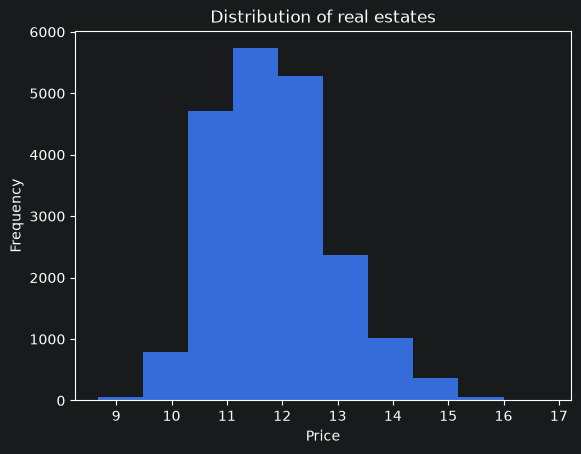

In [112]:
# Histogram that demonstrates price and surface area distribution.
fig,ax=plt.subplots() # Subplots is not mandatory but it is useful mostly if you want to create multiple plots in a single figure.
ax.hist(np.log1p(real_estate_df['price_aprox_usd'])) # I take log of price to better visualize the distribution we take log1p because log can't handle 0 but log1p(x) can because it handles 1+x.
ax.set_title('Distribution of real estates')
ax.set_xlabel('Price')
ax.set_ylabel('Frequency')

Text(0.5, 0, 'Covered Surface Area')

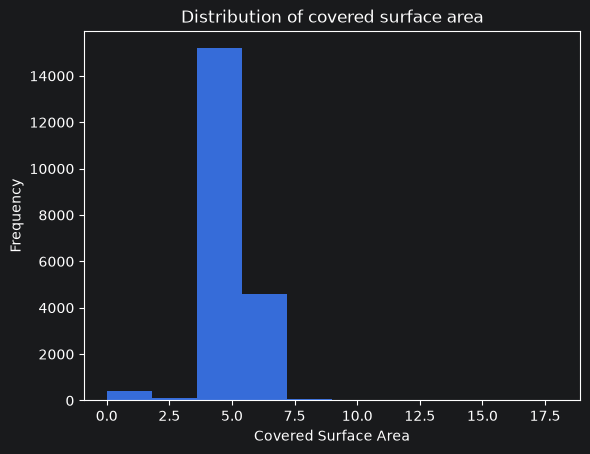

In [113]:
# Distribution of covered surface area and Frequency. We take log1p for reason stated above.
fig,ax=plt.subplots()
ax.hist(np.log1p(real_estate_df['surface_covered_in_m2']))
ax.set_title('Distribution of covered surface area')
ax.set_ylabel('Frequency')
ax.set_xlabel('Covered Surface Area')

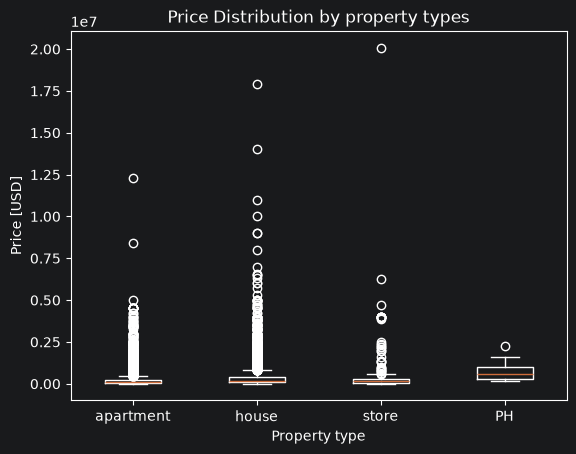

In [114]:
# Price Distribution by property types displayed through boxplot. Boxplot is a great way to see five point summary btw, it's specially helpful to identify outliers in data. As you can see, here there are lots of outliers which will skew data a lot.
property_types = real_estate_df['property_type'].unique()
data_by_type = [real_estate_df[real_estate_df['property_type'] == ptype]["price_aprox_usd"] for ptype in property_types]
fig, ax = plt.subplots()
ax.boxplot(data_by_type, tick_labels=property_types)
ax.set_title('Price Distribution by property types')
ax.set_xlabel('Property type')
ax.set_ylabel('Price [USD]')
plt.show()

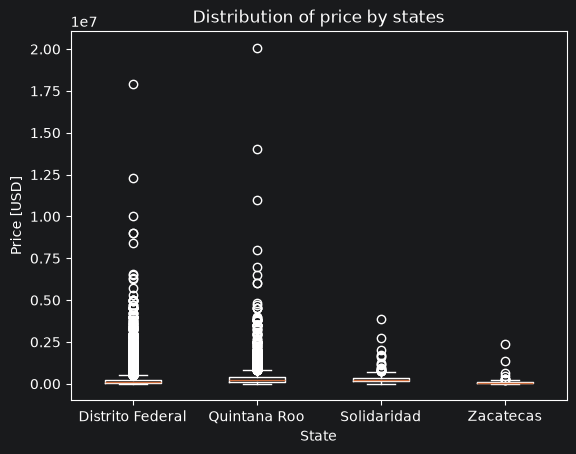

In [115]:
# I decide to take the 4 top states because it is not easy to visualize the rest of the states. If you are curious about it, you can check them by tinkering with the code. In this notebook however only these 4 shall be used.
topstates=(real_estate_df['state']
    .value_counts()
    .head(4)
    .index.tolist())

data_state=[real_estate_df[real_estate_df['state']==state]["price_aprox_usd"] for state in topstates]
fig, ax= plt.subplots()
ax.boxplot(data_state,tick_labels=topstates)
ax.set_title("Distribution of price by states")
ax.set_xlabel("State")
ax.set_ylabel("Price [USD]")
plt.show()

In [116]:
# Just now, we saw how the outliers are dominant in dataset, that's why i use the percentiles to remove the top and below 10th percentiles from dataset.
lower_limit = 0.10
upper_limit = 0.90
df = real_estate_df
df_clean=(df[
        (df["price_aprox_usd"] > df["price_aprox_usd"].quantile(lower_limit)) &
        (df["price_aprox_usd"] < df["price_aprox_usd"].quantile(upper_limit)) &
        (df["surface_covered_in_m2"] > df["surface_covered_in_m2"].quantile(lower_limit)) &
        (df["surface_covered_in_m2"] < df["surface_covered_in_m2"].quantile(upper_limit))
    ]
)


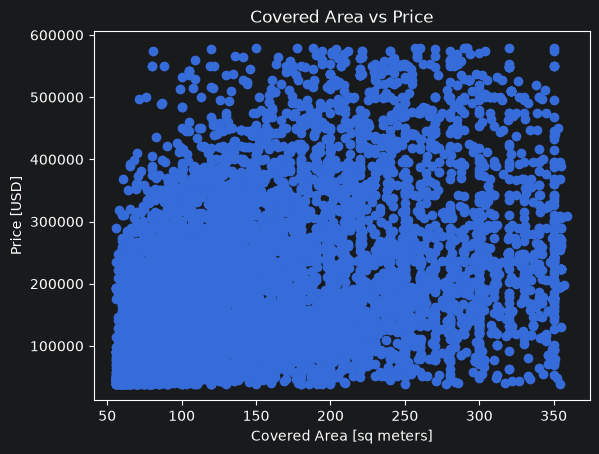

In [117]:
# Scatterplot to visualize the relationship between covered area and price. I use the now cleaned dataset to visualize the relationship. Scatterplot is a great way to visualize though it can be messy if there are too many points, and you might need a regression line to visualize better. As you can see in this plot, we have no real idea regarding the trend of data.
fig, ax = plt.subplots()
ax.scatter(df_clean["surface_covered_in_m2"], df_clean["price_aprox_usd"])
ax.set_title("Covered Area vs Price")
ax.set_xlabel("Covered Area [sq meters]")
ax.set_ylabel("Price [USD]")
plt.show()

<Axes: xlabel='surface_covered_in_m2', ylabel='price_aprox_usd'>

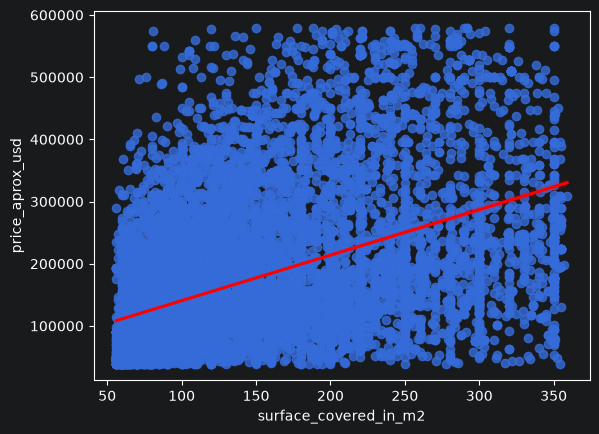

In [118]:
# Hence, we use the regression line to make sense of the figure. This line tells us that there is a moderately positive correlation berween the two features.
import seaborn as sns
fig, ax = plt.subplots()
sns.regplot(
    data=df_clean,
    x="surface_covered_in_m2",
    y="price_aprox_usd",
    line_kws={"color": "red"},
)

In [119]:
# Now, I arrange the states by their mean price in ascending order.
mean_state=df_clean.groupby('state')['price_aprox_usd'].mean().sort_values()

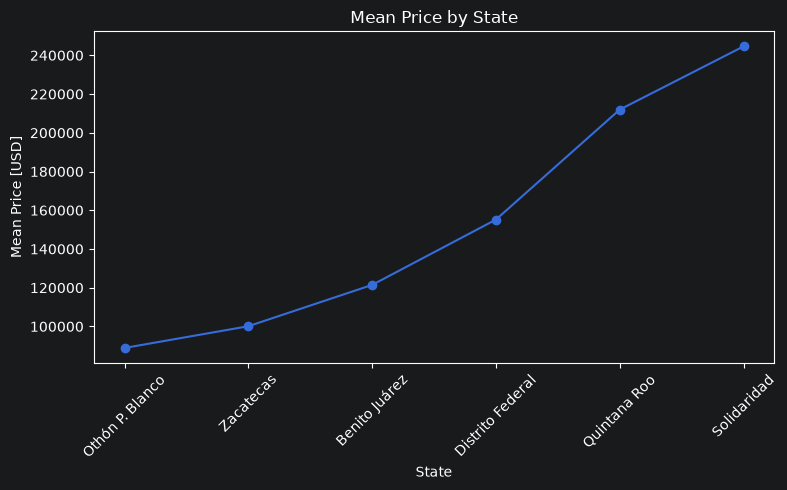

In [120]:
# Now, visualizing the mean price differences by state through a line graph. Line graph are used to represent a trend, specially in time series data.
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(mean_state.index, mean_state.values, marker="o")
ax.set_title("Mean Price by State")
ax.set_xlabel("State")
ax.set_ylabel("Mean Price [USD]")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

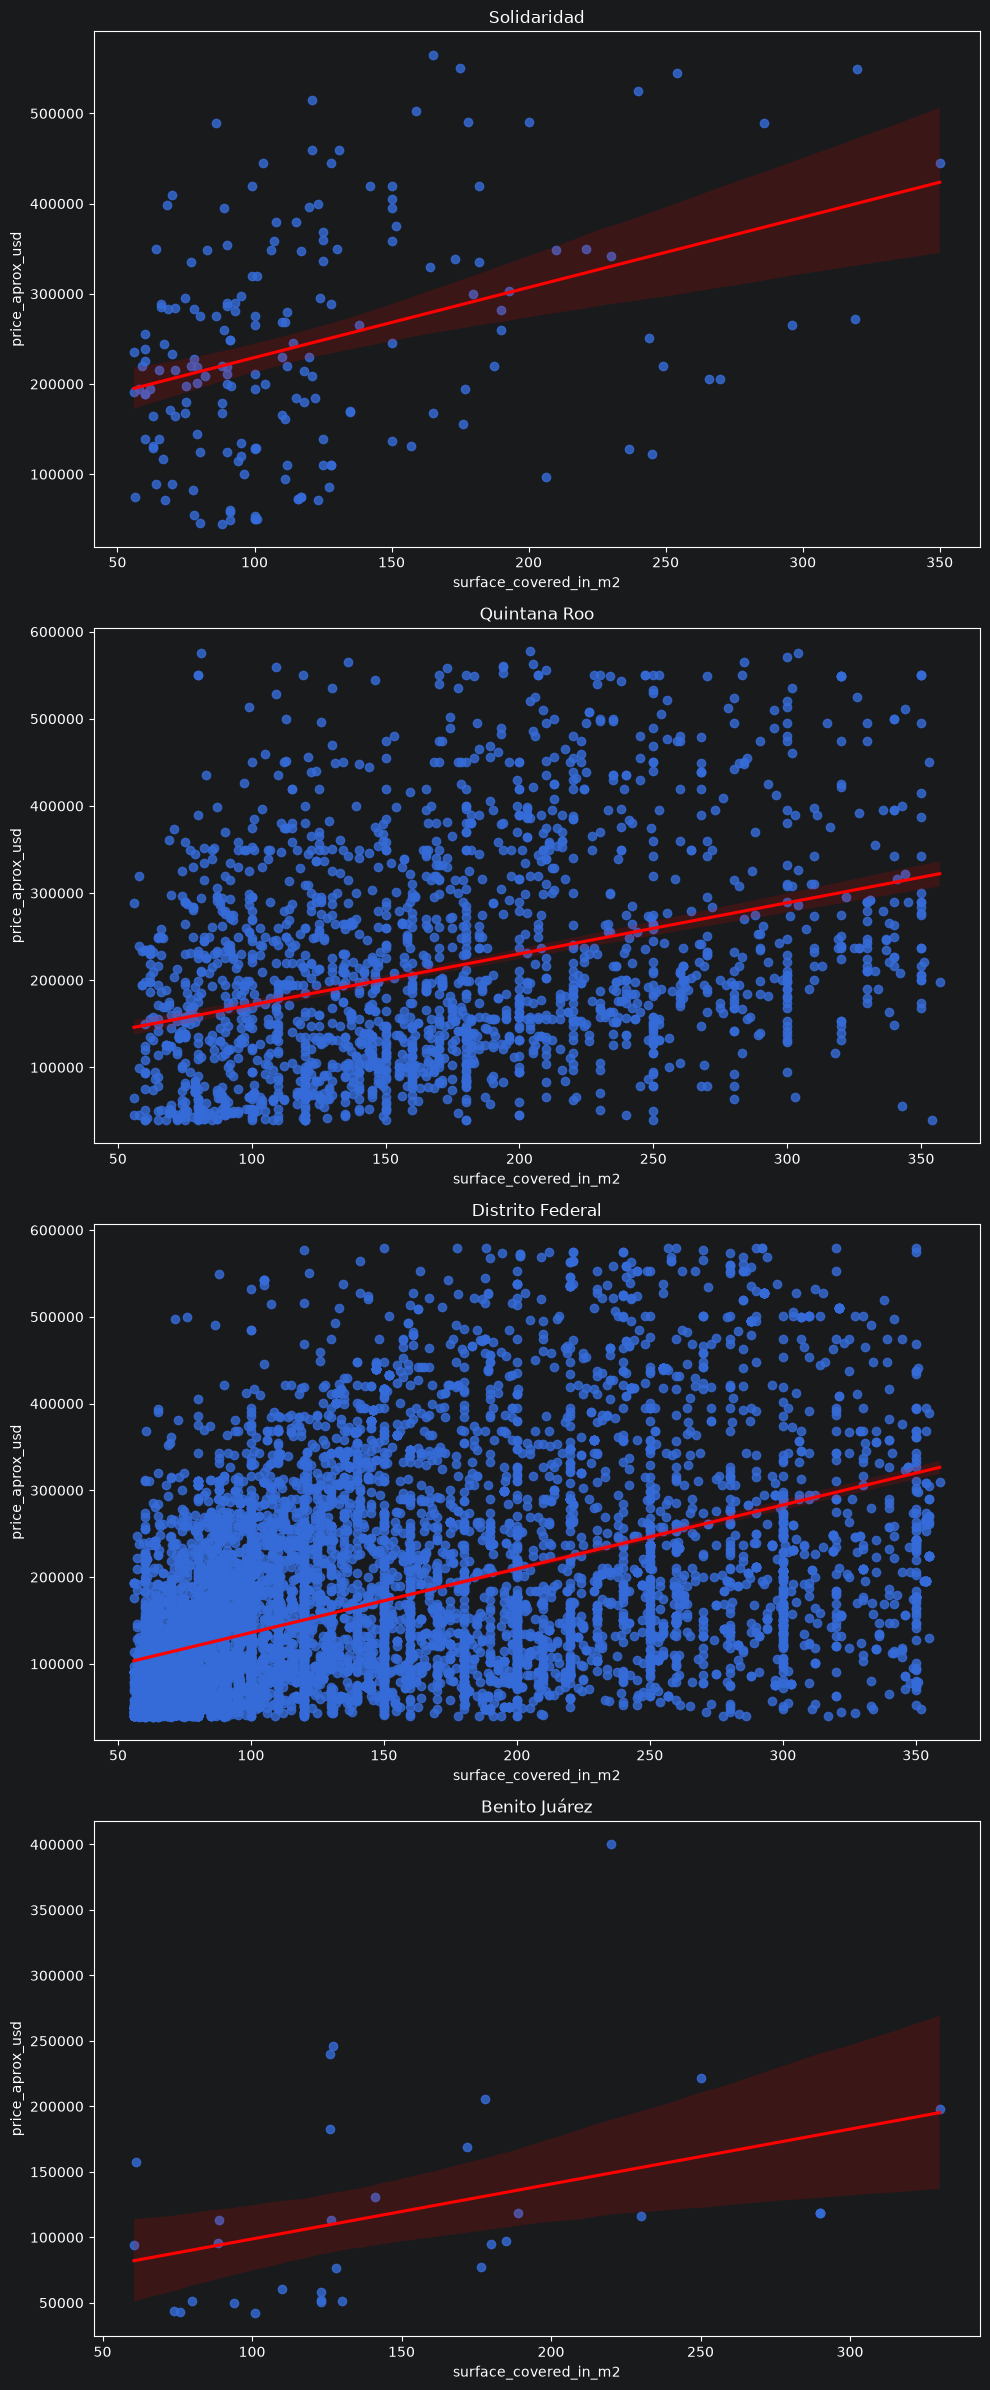

In [121]:
# I select top 4 states based on their mean price to visualize the relationship between covered area and price. I use regression line to visualize the trend based on the individual states.
top_mean_states = (
    df_clean.groupby("state")["price_aprox_usd"]
    .mean()
    .sort_values(ascending=False)
    .head(4)
    .index
    .tolist()
)

n = len(top_mean_states)
fig, axes = plt.subplots(n, 1, figsize=(10, 6 * n))
if n == 1:
    axes = [axes]

for ax, state in zip(axes, top_mean_states):
    sample = df_clean[df_clean["state"] == state]
    sns.regplot(
        data=sample,
        x="surface_covered_in_m2",
        y="price_aprox_usd",
        line_kws={"color": "red"},
        ax=ax,
    )
    ax.set_title(state)
plt.tight_layout()
plt.show()



In [122]:
print(f"Mean price by state:\n{mean_state.to_string()}")

Mean price by state:
state
Othón P. Blanco      88888.063333
Zacatecas           100113.235345
Benito Juárez       121445.046667
Distrito Federal    155170.304321
Quintana Roo        211973.243818
Solidaridad         244603.074185


In [123]:
corr_price_area=df_clean["surface_covered_in_m2"].corr(df_clean['price_aprox_usd'])
print(f'The correlation between area and price of property is {corr_price_area}') # Here I calculate the correlation between two features, the correlation is moderately positive.

The correlation between area and price of property is 0.4755692957376212


In [124]:
corr_matrix = (
    df_clean
    .select_dtypes("number") # to select the numeric data only
    .corr()
)

corr_matrix

,price_aprox_usd,surface_covered_in_m2,lat,lon
price_aprox_usd,1.000000,0.475569,0.127865,0.180239
surface_covered_in_m2,0.475569,1.000000,0.131568,0.188991
lat,0.127865,0.131568,1.000000,0.566629
lon,0.180239,0.188991,0.566629,1.000000


Text(0.5, 1.0, 'Correlation Matrix for numerical features of Real Estate Data')

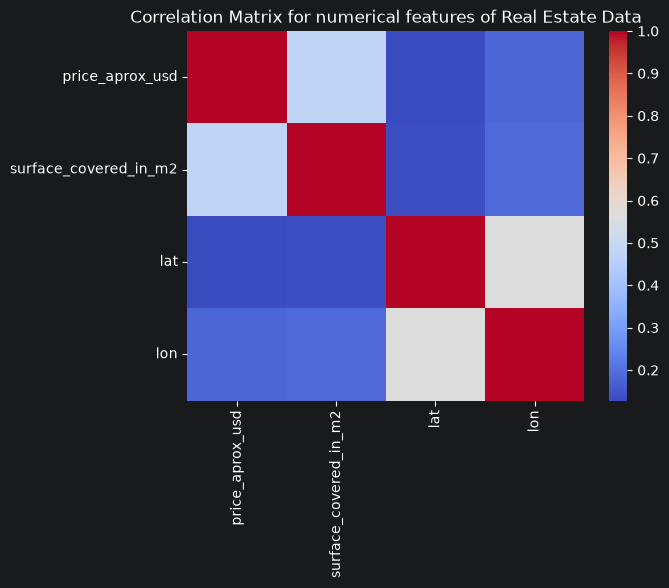

In [125]:
fig,ax=plt.subplots()
sns.heatmap(corr_matrix,cmap='coolwarm',ax=ax)
ax.set_title('Correlation Matrix for numerical features of Real Estate Data')

In [126]:
(df_clean.groupby("state")[['surface_covered_in_m2','price_aprox_usd']]
 .corr()
 .iloc[:,1]
 .xs('surface_covered_in_m2',level=1))


state
Benito Juárez       0.390970
Distrito Federal    0.488384
Othón P. Blanco     0.867826
Quintana Roo        0.343938
Solidaridad         0.358097
Zacatecas           0.507406
Name: price_aprox_usd, dtype: float64

In [127]:
(df_clean.groupby('property_type')[['surface_covered_in_m2','price_aprox_usd']]
 .corr()
 .iloc[:,1]
 .xs('surface_covered_in_m2',level=1)
)



property_type
PH          -0.291176
apartment    0.625476
house        0.450582
store        0.308284
Name: price_aprox_usd, dtype: float64

In [128]:
data = (
    df_clean
    .assign(price_per_m2=lambda x: x["price_aprox_usd"] / x["surface_covered_in_m2"])
)


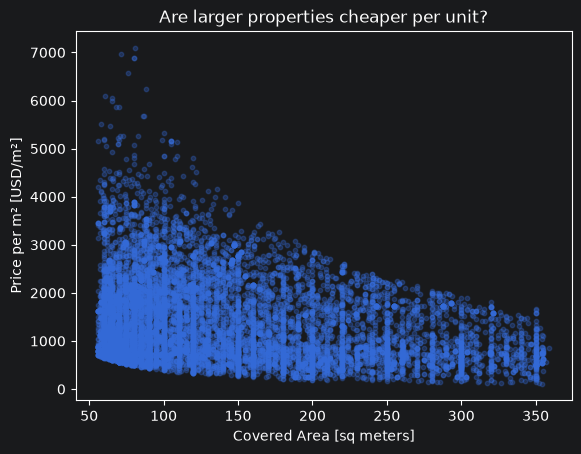

In [129]:
fig, ax = plt.subplots()
ax.scatter(data["surface_covered_in_m2"], data["price_per_m2"], alpha=0.3, s=10)
ax.set_title("Are larger properties cheaper per unit?")
ax.set_xlabel("Covered Area [sq meters]")
ax.set_ylabel("Price per m² [USD/m²]")
plt.show()

In [130]:
# We raised a question in the previous cell, now we can answer it by calculating the correlation between the two features. The correlation is negative, which means that larger properties are cheaper per unit as we look through the plot. Now to confirm it using correlation coefficient.
corr = data["surface_covered_in_m2"].corr(data["price_per_m2"])
print(f"The correlation between area and price per unit is {corr:.3f}")
# While the figure told us the relationship was negative, the coefficient confirms the strength of relationship. The correlation is moderately negative.

The correlation between area and price per unit is -0.227


# Modeling

In [131]:
# defining x and y as labeled data where x is the feature matrix and y is target vector.
y = df_clean["price_aprox_usd"]
X = df_clean[["surface_covered_in_m2", "property_type", "state"]].copy()
# The following parts are the parts I know nothing about, I am implementing these while learning about them. I will try to understand and explain the concept behind as simply as possible.
for col in ["property_type", "state"]: # We use both the features becuase we need to convert them into numerical features for the model to understand. We use one-hot encoding to convert them into numerical features.
    top_level = X[col].value_counts().idxmax() # We use the top-most occurence as reference level. This is done so because model is going to use it as a reference for other values.
    ordered_levels = [top_level] + sorted(lv for lv in X[col].unique() if lv != top_level)# We sort the levels in ascending order and put the reference level at the top.
    X[col] = pd.Categorical(X[col], categories=ordered_levels) # We convert these columns into categorical datatypes using ordered_levels as category.
# We use get_dummies to drop the first level of categorical feature and make it the baseline reference and avoid multicollinearity.                 

# What is multicollinearity? Multicollinearity means there are independent but highly correlated data features, this means that using one of those features can display the property of multiple features.
X = pd.get_dummies(
    X,
    columns=["property_type", "state"],
    drop_first=True,
    dtype=float,
)

print("Feature matrix shape:", X.shape)
print("Target vector length:", len(y))
print()
print("Feature columns:")
print(X.columns.tolist())
print()
print("Feature matrix head:")
print(X.head())

Feature matrix shape: (13968, 9)
Target vector length: 13968

Feature columns:
['surface_covered_in_m2', 'property_type_PH', 'property_type_house', 'property_type_store', 'state_Benito Juárez', 'state_Othón P. Blanco', 'state_Quintana Roo', 'state_Solidaridad', 'state_Zacatecas']

Feature matrix head:
   surface_covered_in_m2  property_type_PH  property_type_house  \
1                   80.0               0.0                  1.0   
2                  100.0               0.0                  0.0   
3                  135.0               0.0                  0.0   
5                   87.0               0.0                  0.0   
6                  100.0               0.0                  0.0   

   property_type_store  state_Benito Juárez  state_Othón P. Blanco  \
1                  0.0                  0.0                    0.0   
2                  0.0                  0.0                    0.0   
3                  0.0                  0.0                    0.0   
5             

In [132]:
y_log = np.log1p(y)
# We take log1 value of y for standarization
print("Raw target summary:")
print(y.describe())
print()
print("Log-target summary:")
print(pd.Series(y_log).describe())

Raw target summary:
count     13968.000000
mean     164578.030638
std      115139.703267
min       39251.430000
25%       76922.260000
50%      131716.200000
75%      218700.187500
max      579551.320000
Name: price_aprox_usd, dtype: float64

Log-target summary:
count    13968.000000
mean        11.784042
std          0.677241
min         10.577769
25%         11.250564
50%         11.788412
75%         12.295462
max         13.270011
Name: price_aprox_usd, dtype: float64


In [133]:
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log,
    test_size=0.20,
    random_state=42,
)
# We split the dataset by 80:20 as training and testing data.
y_train = np.expm1(y_train_log)
y_test = np.expm1(y_test_log)

print(f"Training set: {X_train.shape[0]} rows, {X_train.shape[1]} features")
print(f"Test set:     {X_test.shape[0]} rows, {X_test.shape[1]} features")

Training set: 11174 rows, 9 features
Test set:     2794 rows, 9 features


In [134]:
def get_rmse(model, X, y_true):
    """
    Calculate RMSE for a given model and dataset.

    Parameters:
    -----------
    model : fitted sklearn model or pipeline
    X : features (DataFrame or array)
    y_true : true target values

    Returns:
    --------
    float : RMSE value
    """
    # Models are trained on log1p(price); evaluate after converting back to USD.
    y_pred = np.expm1(model.predict(X))
    rmse = root_mean_squared_error(y_true, y_pred) # <--- y_true, y_pred
    return rmse

# Test the function
print("Function created successfully!")

Function created successfully!


BaseLine Model

In [135]:
# Baseline prediction on the same log-target scale as the models
y_mean_log = y_train_log.mean()

# Create baseline predictions
y_pred_baseline_train = [np.expm1(y_mean_log)] * len(y_train)
y_pred_baseline_test = [np.expm1(y_mean_log)] * len(y_test)

# Calculate RMSE
rmse_base_train = root_mean_squared_error(y_train, y_pred_baseline_train)  # root_mean_squared_error(y_train, y_pred_baseline_train)
rmse_base_test = root_mean_squared_error(y_test, y_pred_baseline_test)  # root_mean_squared_error(y_test, y_pred_baseline_test)

print(f"Baseline Train RMSE: ${rmse_base_train:,.2f}")
print(f"Baseline Test RMSE: ${rmse_base_test:,.2f}")

Baseline Train RMSE: $119,939.64
Baseline Test RMSE: $119,885.43


Linear Regression Model

In [136]:
model_linear =make_pipeline(
    OneHotEncoder(use_cat_names=True),
    StandardScaler(),
    LinearRegression()
)

model_linear.fit(X_train, y_train_log)  # X_train, log-transformed target

rmse_linear_train = get_rmse(model_linear, X_train, y_train)  # model_linear, X_train, y_train
rmse_linear_test = get_rmse(model_linear, X_test, y_test)  # model_linear, X_test, y_test

print(f"Linear Regression Train RMSE: ${rmse_linear_train:,.2f}")
print(f"Linear Regression Test RMSE: ${rmse_linear_test:,.2f}")

Linear Regression Train RMSE: $101,292.42
Linear Regression Test RMSE: $101,576.56


In [137]:
model_ridge = make_pipeline(
    OneHotEncoder(use_cat_names=True),  # True
    StandardScaler(),
    RidgeCV(alphas=np.logspace(-2,4,100))  # np.logspace(-2, 4, 100)
)

model_ridge.fit(X_train, y_train_log)  # X_train, log-transformed target

rmse_ridge_train = get_rmse(model_ridge, X_train, y_train)  # model_ridge, X_train, y_train
rmse_ridge_test = get_rmse(model_ridge, X_test, y_test)  # model_ridge, X_test, y_test

# Extract the tuned alpha value
alpha_ridge_chosen = model_ridge.named_steps["ridgecv"].alpha_
print(f"Best Ridge alpha: {alpha_ridge_chosen:.6f}")
print(f"Ridge Train RMSE: ${rmse_ridge_train:,.2f}")
print(f"Ridge Test RMSE: ${rmse_ridge_test:,.2f}")

Best Ridge alpha: 12.328467
Ridge Train RMSE: $101,287.29
Ridge Test RMSE: $101,576.36


In [138]:
model_lasso = make_pipeline(
    OneHotEncoder(use_cat_names=True),  # True
    StandardScaler(),
    LassoCV(alphas=np.logspace(-4,2,100), max_iter=10000)  # np.logspace(-4, 2, 100)
)

model_lasso.fit(X_train, y_train_log)  # X_train, log-transformed target

rmse_lasso_train = get_rmse(model_lasso, X_train, y_train)  # model_lasso, X_train, y_train
rmse_lasso_test = get_rmse(model_lasso, X_test, y_test)  # model_lasso, X_test, y_test

# Extract the tuned alpha value
alpha_lasso_chosen = model_lasso.named_steps["lassocv"].alpha_
print(f"Best Lasso alpha: {alpha_lasso_chosen:.6f}")
print(f"Lasso Train RMSE: ${rmse_lasso_train:,.2f}")
print(f"Lasso Test RMSE: ${rmse_lasso_test:,.2f}")

Best Lasso alpha: 0.000100
Lasso Train RMSE: $101,291.61
Lasso Test RMSE: $101,578.50


In [139]:
# Build Results Table
data = {
    "Model": ["Baseline", "Linear Regression", "Ridge (CV-tuned)", "Lasso (CV-tuned)"],
    "Train_RMSE": [
        rmse_base_train,
        rmse_linear_train,  # rmse_linear_train
        rmse_ridge_train,  # rmse_ridge_train
        rmse_lasso_train   # rmse_lasso_train
    ],
    "Test_RMSE": [
        rmse_base_test,
        rmse_linear_test,  # rmse_linear_test
        rmse_ridge_test,  # rmse_ridge_test
        rmse_lasso_test   # rmse_lasso_test
    ]
}

df_results = pd.DataFrame(data)

# Calculate Generalization Gap
df_results["Gap"] = df_results["Test_RMSE"] - df_results["Train_RMSE"]

# Set Model as index for better display
df_results = df_results.set_index("Model")

print("\n" + "="*60)
print("MODEL COMPARISON TABLE")
print("="*60)
print(df_results.round(2))
print("="*60)


MODEL COMPARISON TABLE
                   Train_RMSE  Test_RMSE     Gap
Model                                           
Baseline            119939.64  119885.43  -54.20
Linear Regression   101292.42  101576.56  284.13
Ridge (CV-tuned)    101287.29  101576.36  289.07
Lasso (CV-tuned)    101291.61  101578.50  286.89


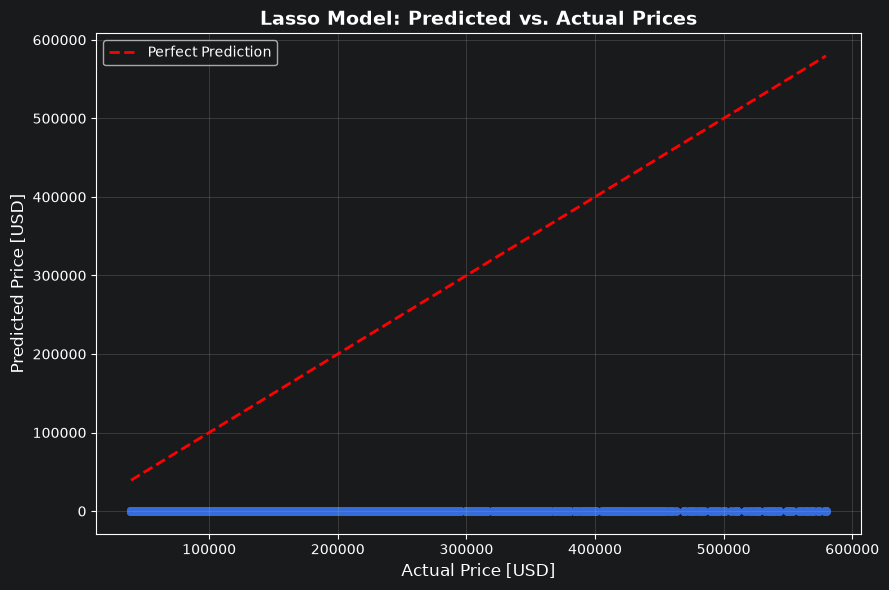

In [140]:
y_pred_lasso = model_lasso.predict(X_test)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(y_test, y_pred_lasso, linewidth=0.5)

ideal_line = np.linspace(y_test.min(), y_test.max(), 100)
ax.plot(ideal_line, ideal_line, color="red", linestyle="--", linewidth=2, label="Perfect Prediction")

ax.set_xlabel("Actual Price [USD]", fontsize=12)
ax.set_ylabel("Predicted Price [USD]", fontsize=12)
ax.set_title("Lasso Model: Predicted vs. Actual Prices", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

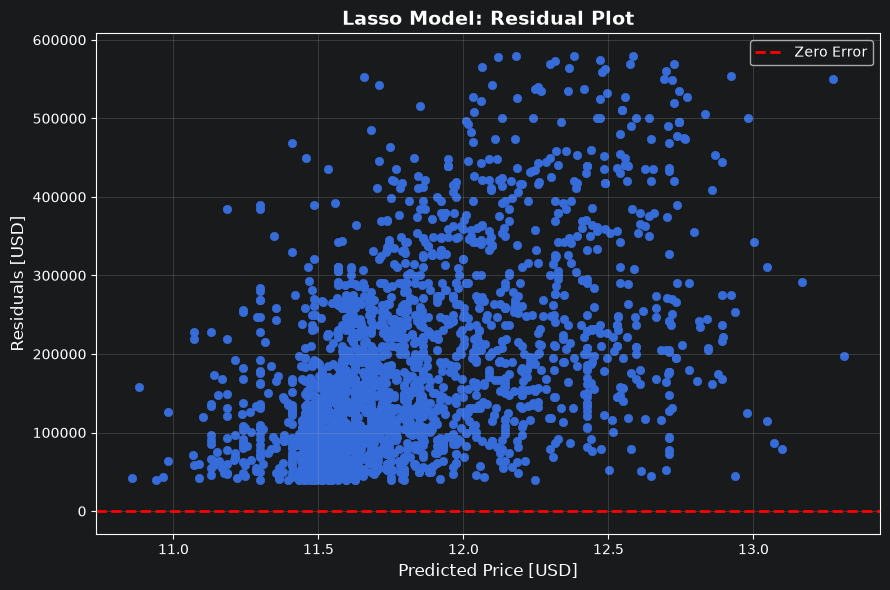

In [141]:
residuals = y_test - y_pred_lasso

fig_res, ax_res = plt.subplots(figsize=(9, 6))
ax_res.scatter(y_pred_lasso, residuals, linewidth=0.5)
ax_res.axhline(y=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
ax_res.set_xlabel("Predicted Price [USD]", fontsize=12)
ax_res.set_ylabel("Residuals [USD]", fontsize=12)
ax_res.set_title("Lasso Model: Residual Plot", fontsize=14, fontweight='bold')
ax_res.legend(fontsize=10)
ax_res.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [142]:
# Find which model has the lowest test RMSE
best_model = df_results["Test_RMSE"].idxmin()

recommendation = f"""
=================================================================
FINAL MODEL SELECTION REPORT
=================================================================

SUMMARY:
Based on comprehensive evaluation, I recommend the {best_model} model
for production deployment.

PERFORMANCE COMPARISON:
- Baseline Test RMSE: ${rmse_base_test:,.2f}
- Linear Regression Test RMSE: ${rmse_linear_test:,.2f}
- Ridge (CV-tuned) Test RMSE: ${rmse_ridge_test:,.2f}
- Lasso (CV-tuned) Test RMSE: ${rmse_lasso_test:,.2f}

=================================================================
"""

print(recommendation)


FINAL MODEL SELECTION REPORT

EXECUTIVE SUMMARY:
Based on comprehensive evaluation, I recommend the Ridge (CV-tuned) model
for production deployment.

PERFORMANCE COMPARISON:
- Baseline Test RMSE: $119,885.43
- Linear Regression Test RMSE: $101,576.56
- Ridge (CV-tuned) Test RMSE: $101,576.36
- Lasso (CV-tuned) Test RMSE: $101,578.50


